In [1]:
# Bibliotheken importieren
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold

matplotlib.rcParams['figure.dpi'] = 150

# Daten laden
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
sex_train = pd.read_csv('../data/sex_train.csv').squeeze()
sex_test  = pd.read_csv('../data/sex_test.csv').squeeze()

# Gesamten Feature-Space für Cross-Validation zusammenführen
X_all   = pd.concat([X_train, X_test], ignore_index=True)
sex_all = pd.concat([sex_train, sex_test], ignore_index=True)

In [2]:
# Logistische Regression trainieren
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

proxy_model = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
auc_scores = cross_val_score(proxy_model, X_all, sex_all, cv=cv, scoring='roc_auc')

print("Multivariate Proxy-AUC (5-Fold CV):")
print("  Scores:", auc_scores.round(4))
print("  Mittelwert:", round(auc_scores.mean(), 4))
print("  Standardabweichung:", round(auc_scores.std(), 4))

print("---")
print("Vergleich:")
print("  Zufallsbaseline:                 AUC = 0.500")
print("  Cramér's V relationship_Husband: V   = 0.580  (bivariat)")
print(f"  Multivariates Proxy-Modell:      AUC = {auc_scores.mean():.3f}  (multivariat)")

Multivariate Proxy-AUC (5-Fold CV):
  Scores: [0.9261 0.9278 0.9319 0.9328 0.9335]
  Mittelwert: 0.9304
  Standardabweichung: 0.0029
---
Vergleich:
  Zufallsbaseline:                 AUC = 0.500
  Cramér's V relationship_Husband: V   = 0.580  (bivariat)
  Multivariates Proxy-Modell:      AUC = 0.930  (multivariat)


In [3]:
# Feature Importance des Proxy-Modells berechnen
proxy_model.fit(X_train, sex_train)

coef_df = pd.DataFrame({
    'Merkmal': X_train.columns,
    'Koeffizient': np.abs(proxy_model.named_steps['clf'].coef_[0])
}).sort_values('Koeffizient', ascending=False).head(10)

print("Top-10-Features des Proxy-Modells:")
print(coef_df.to_string(index=False))

Top-10-Features des Proxy-Modells:
                     Merkmal  Koeffizient
        relationship_Husband     3.192219
           relationship_Wife     1.899282
      relationship_Unmarried     1.115078
  relationship_Not-in-family     1.025276
      relationship_Own-child     0.831238
     occupation_Craft-repair     0.639139
     occupation_Adm-clerical     0.453249
 relationship_Other-relative     0.407825
 occupation_Transport-moving     0.406454
occupation_Handlers-cleaners     0.306020


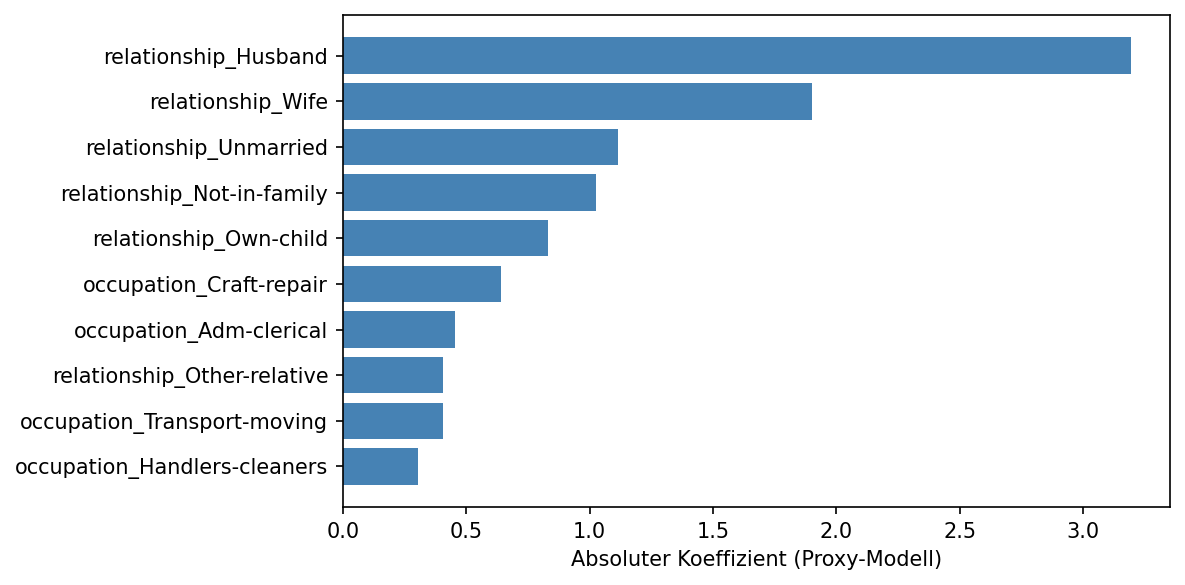

Abbildung gespeichert.


In [4]:
# Visualisierung speichern
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(coef_df['Merkmal'][::-1], coef_df['Koeffizient'][::-1], color='steelblue')
ax.set_xlabel('Absoluter Koeffizient (Proxy-Modell)')
# ax.set_title('Top-10-Features des multivariaten Proxy-Modells')
plt.tight_layout()
plt.savefig('../results/figures/proxy_multivariat.png', bbox_inches='tight')
plt.show()
print("Abbildung gespeichert.")